In [1]:
!pip install squidpy scanpy spatialdata spatialdata-io seaborn matplotlib

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of dask[array] to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of ome-zarr to determine which version is compatible with other requirements. This could take a while.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at

In [2]:
import spatialdata as sd
from spatialdata_io import xenium

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq

In [3]:
xenium_path = "./Xenium"
zarr_path = "./Xenium.zarr"

In [5]:
!pip install squidpy scanpy spatialdata spatialdata-io pooch seaborn matplotlib

In [6]:
import spatialdata as sd
from spatialdata_io import xenium

import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import seaborn as sns
import pooch
import os

In [9]:
!pip install squidpy scanpy spatialdata spatialdata-io seaborn matplotlib

In [10]:
import spatialdata as sd
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
!pip install --upgrade spatialdata

In [2]:
import squidpy as sq

adata = sq.datasets.visium_hne_adata()
adata

INFO     Downloading visium_hne_adata.h5ad from                                                                    
         https://exampledata.scverse.org/squidpy/figshare/visium_hne_adata.h5ad                                    


  0%|                                               | 0.00/329M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [4]:
# install required clustering backend
!pip install leidenalg igraph --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 86.4 MB/s eta 0:00:00


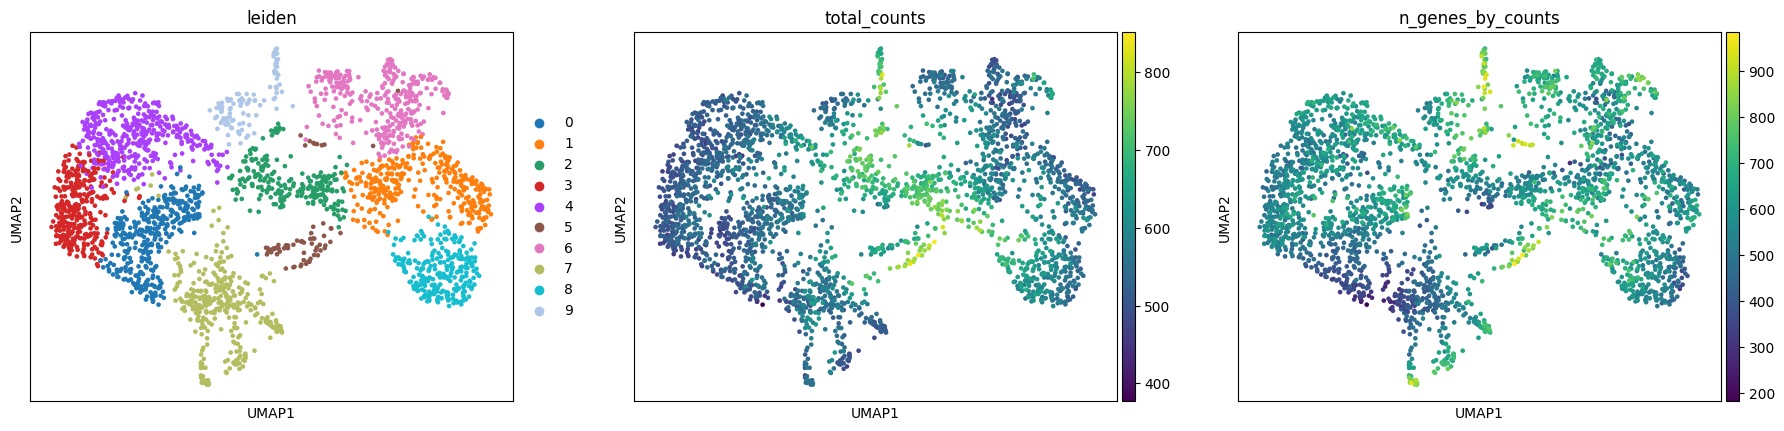

In [5]:
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt

# QC metrics
sc.pp.calculate_qc_metrics(adata, inplace=True)

# Filtering
sc.pp.filter_cells(adata, min_counts=10)
sc.pp.filter_genes(adata, min_cells=5)

# Save raw counts
adata.layers["counts"] = adata.X.copy()

# Normalization
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var["highly_variable"]].copy()   # FIX: avoids warning

# PCA
sc.pp.pca(adata)

# Neighbors
sc.pp.neighbors(adata)

# UMAP + clustering (FIXED)
sc.tl.umap(adata)
sc.tl.leiden(
    adata,
    resolution=0.5,
    flavor="igraph",      # FIX: faster + avoids warning
    n_iterations=2,
    directed=False
)

# Plot
sc.pl.umap(adata, color=["leiden", "total_counts", "n_genes_by_counts"])

In [7]:
adata.uns.pop("leiden_colors", None)

array(['#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc', '#8c564b',
       '#e377c2', '#b5bd61', '#17becf', '#aec7e8', '#ffbb78', '#98df8a',
       '#ff9896', '#c5b0d5', '#c49c94'], dtype=object)

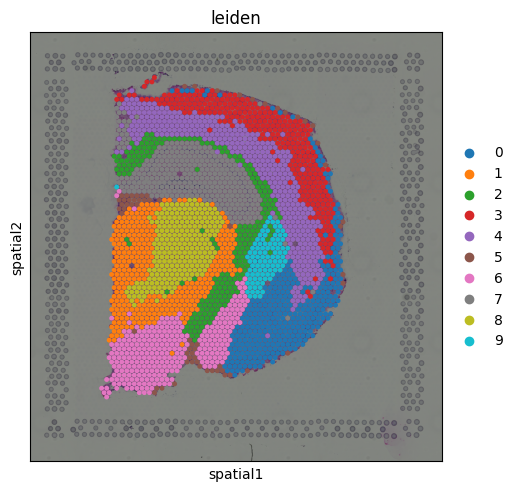

In [8]:
sq.pl.spatial_scatter(
    adata,
    color="leiden",
    size=1.5,
    cmap="tab20"
)

In [9]:
import squidpy as sq

sq.gr.spatial_neighbors(adata, coord_type="grid")

INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           


  0%|          | 0/1000 [00:00<?, ?/s]

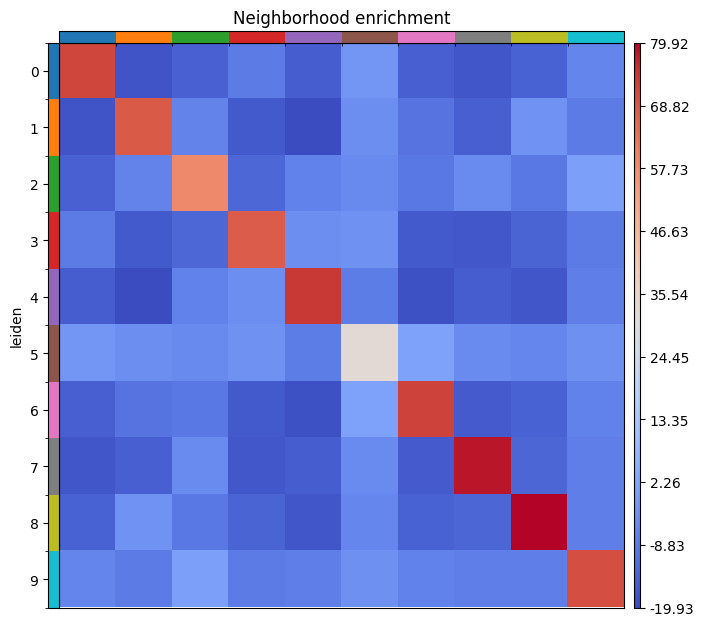

In [10]:
sq.gr.nhood_enrichment(adata, cluster_key="leiden")

sq.pl.nhood_enrichment(
    adata,
    cluster_key="leiden",
    cmap="coolwarm"
)

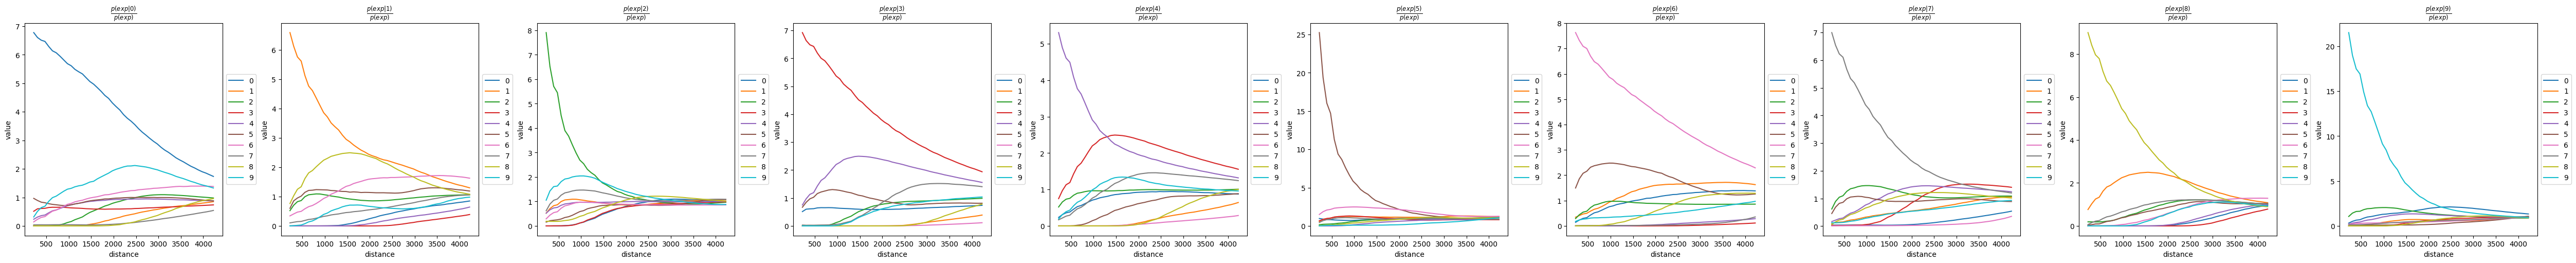

In [11]:
sq.gr.co_occurrence(adata, cluster_key="leiden")

sq.pl.co_occurrence(adata, cluster_key="leiden")

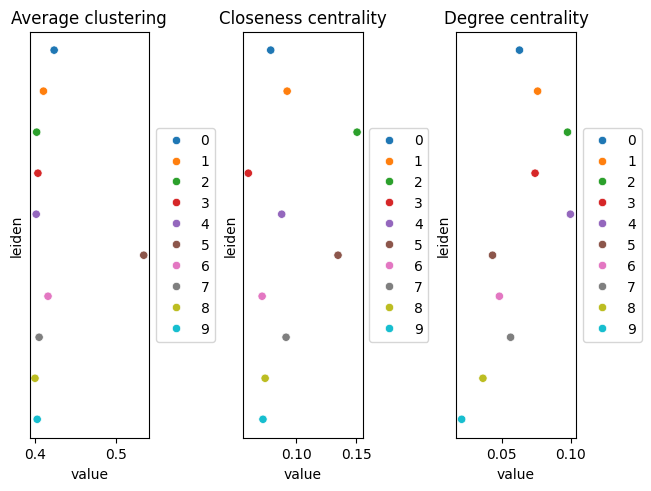

In [12]:
sq.gr.centrality_scores(adata, cluster_key="leiden")

sq.pl.centrality_scores(adata, cluster_key="leiden")

/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered

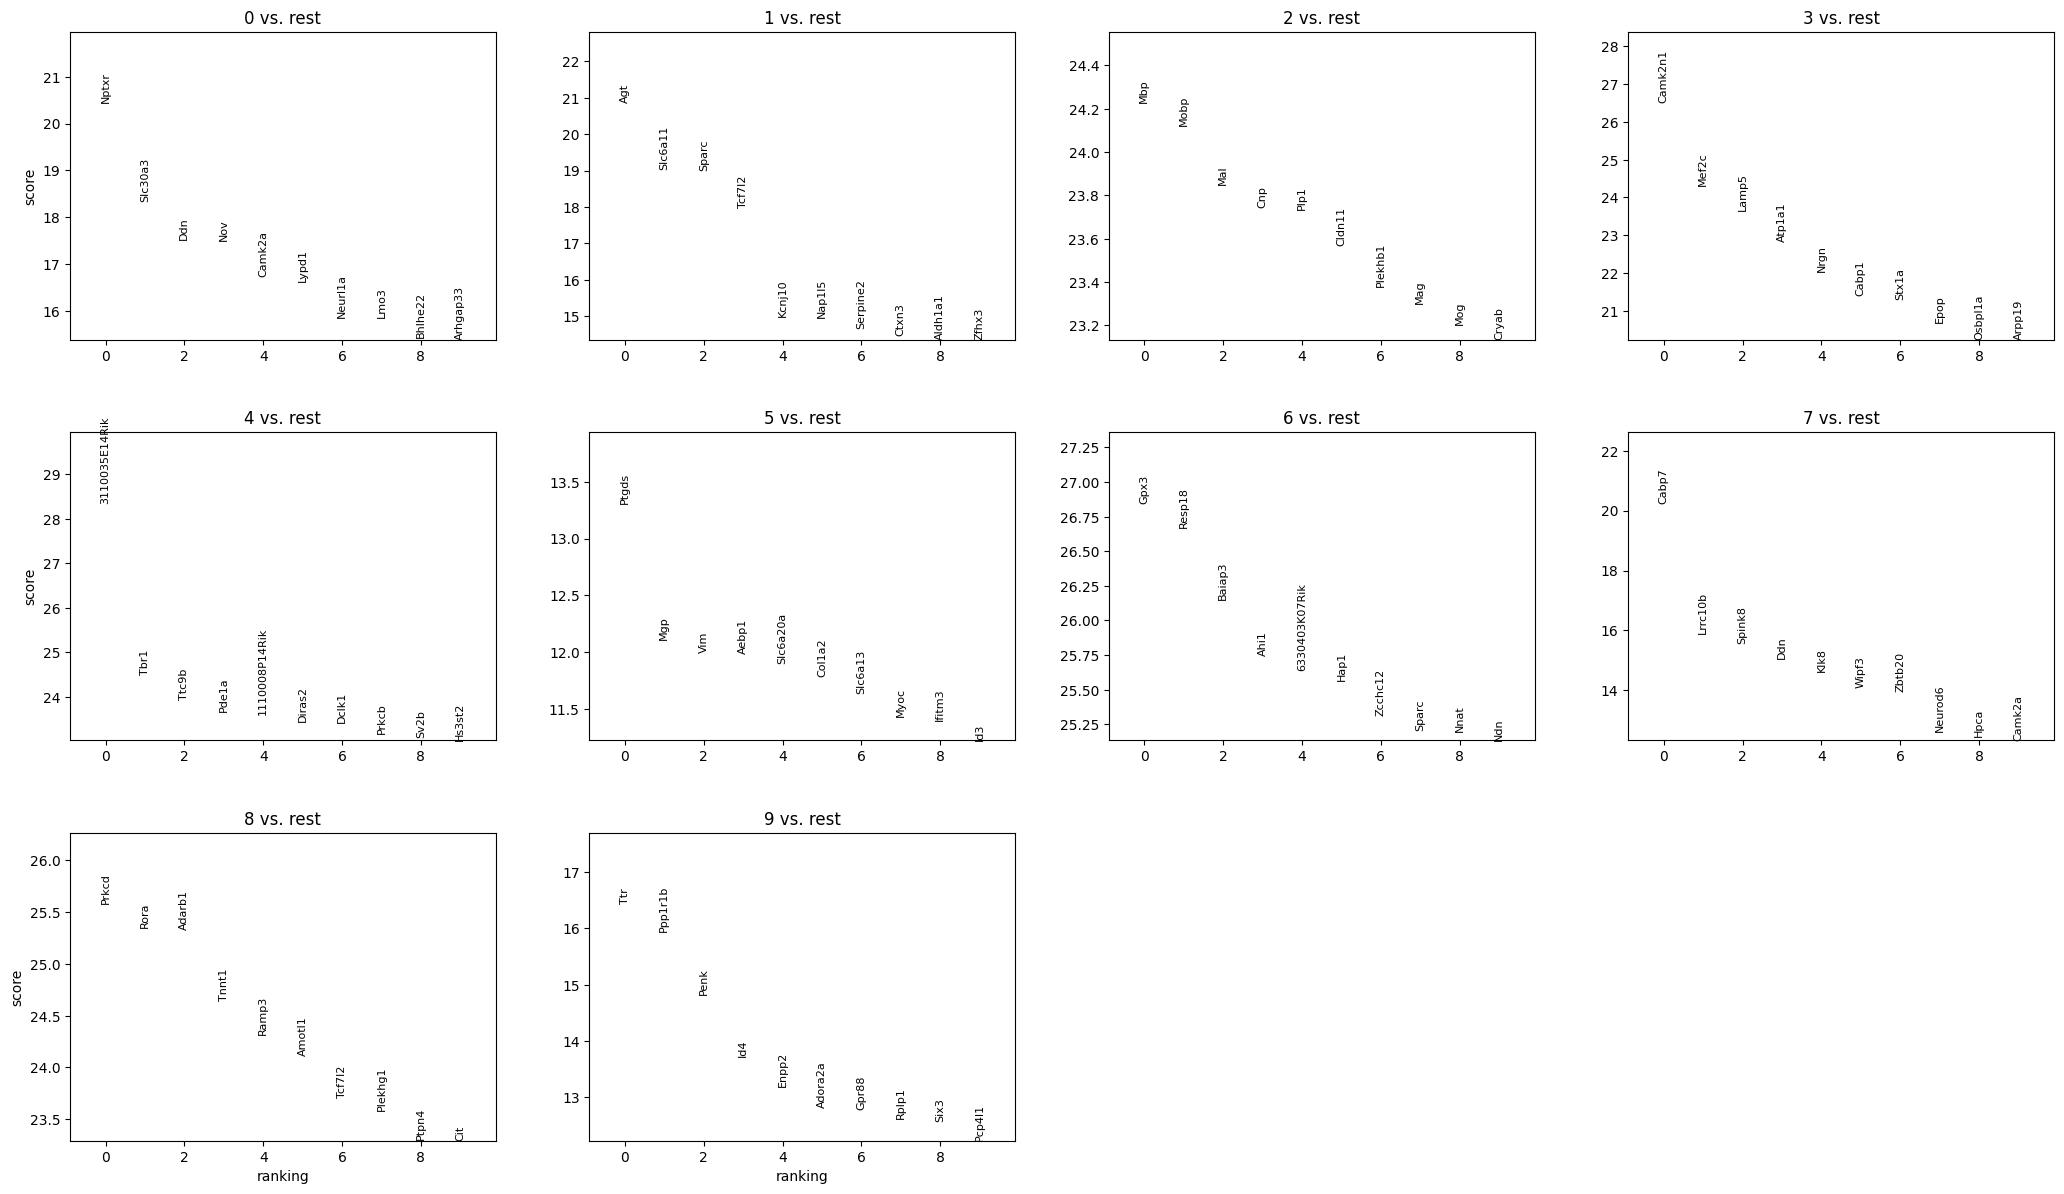

In [13]:
import scanpy as sc

sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon"
)

sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)

In [15]:
import scanpy as sc

sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon"
)

/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered

In [16]:
import numpy as np

# get gene names safely
gene_names = adata.var_names

# take top genes from first cluster safely
top_genes = gene_names[:3]
top_genes

Index(['4732440D04Rik', 'St18', '3110035E14Rik'], dtype='object')

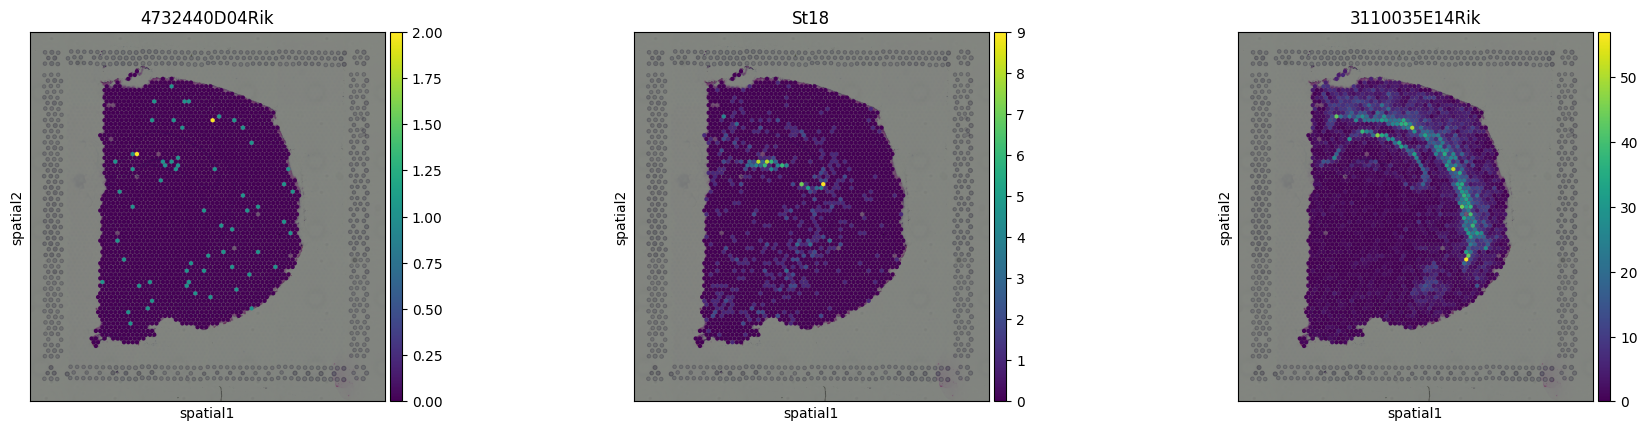

In [17]:
import squidpy as sq

sq.pl.spatial_scatter(
    adata,
    color=list(top_genes),
    size=1.5
)

In [18]:
import scanpy as sc
import squidpy as sq

adata = adata.copy()

In [19]:
sq.gr.spatial_neighbors(adata, coord_type="grid")

INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           


  0%|          | 0/1000 [00:00<?, ?/s]

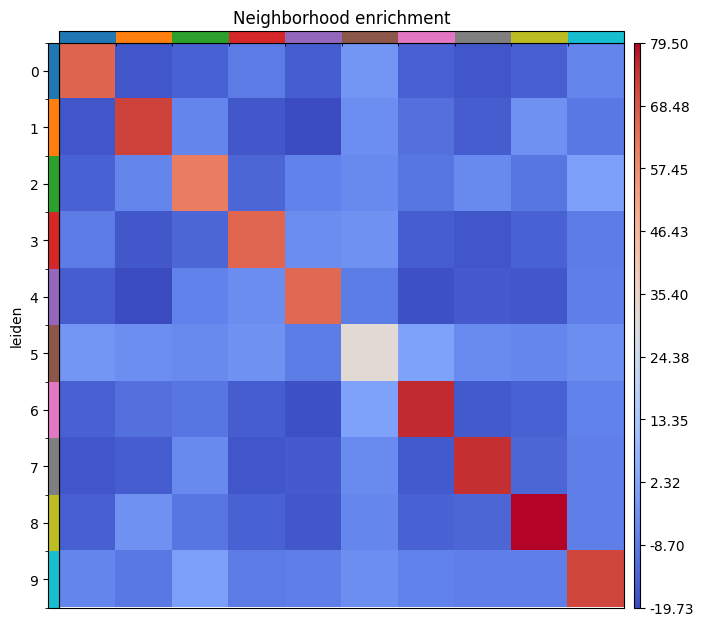

In [20]:
sq.gr.nhood_enrichment(adata, cluster_key="leiden")

sq.pl.nhood_enrichment(
    adata,
    cluster_key="leiden",
    cmap="coolwarm"
)

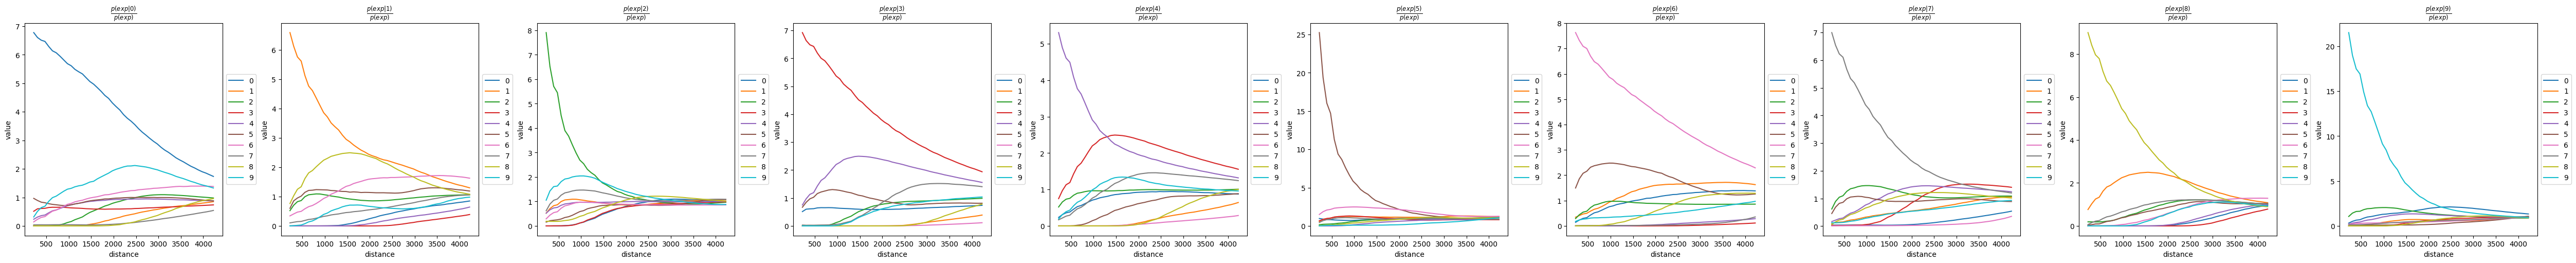

In [21]:
sq.gr.co_occurrence(adata, cluster_key="leiden")

sq.pl.co_occurrence(adata, cluster_key="leiden")

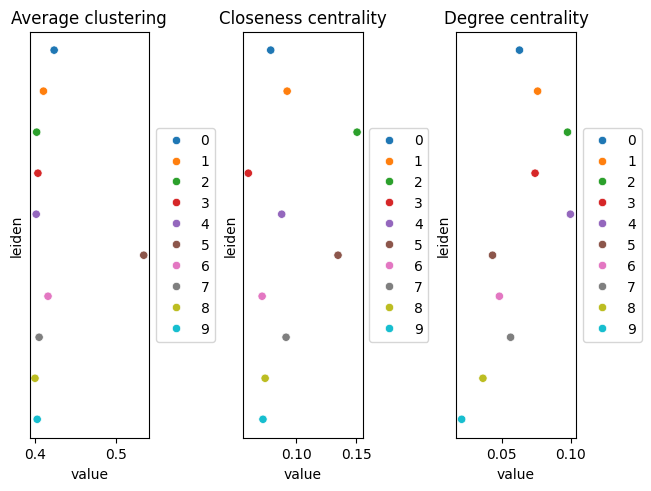

In [22]:
sq.gr.centrality_scores(adata, cluster_key="leiden")

sq.pl.centrality_scores(adata, cluster_key="leiden")

/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered

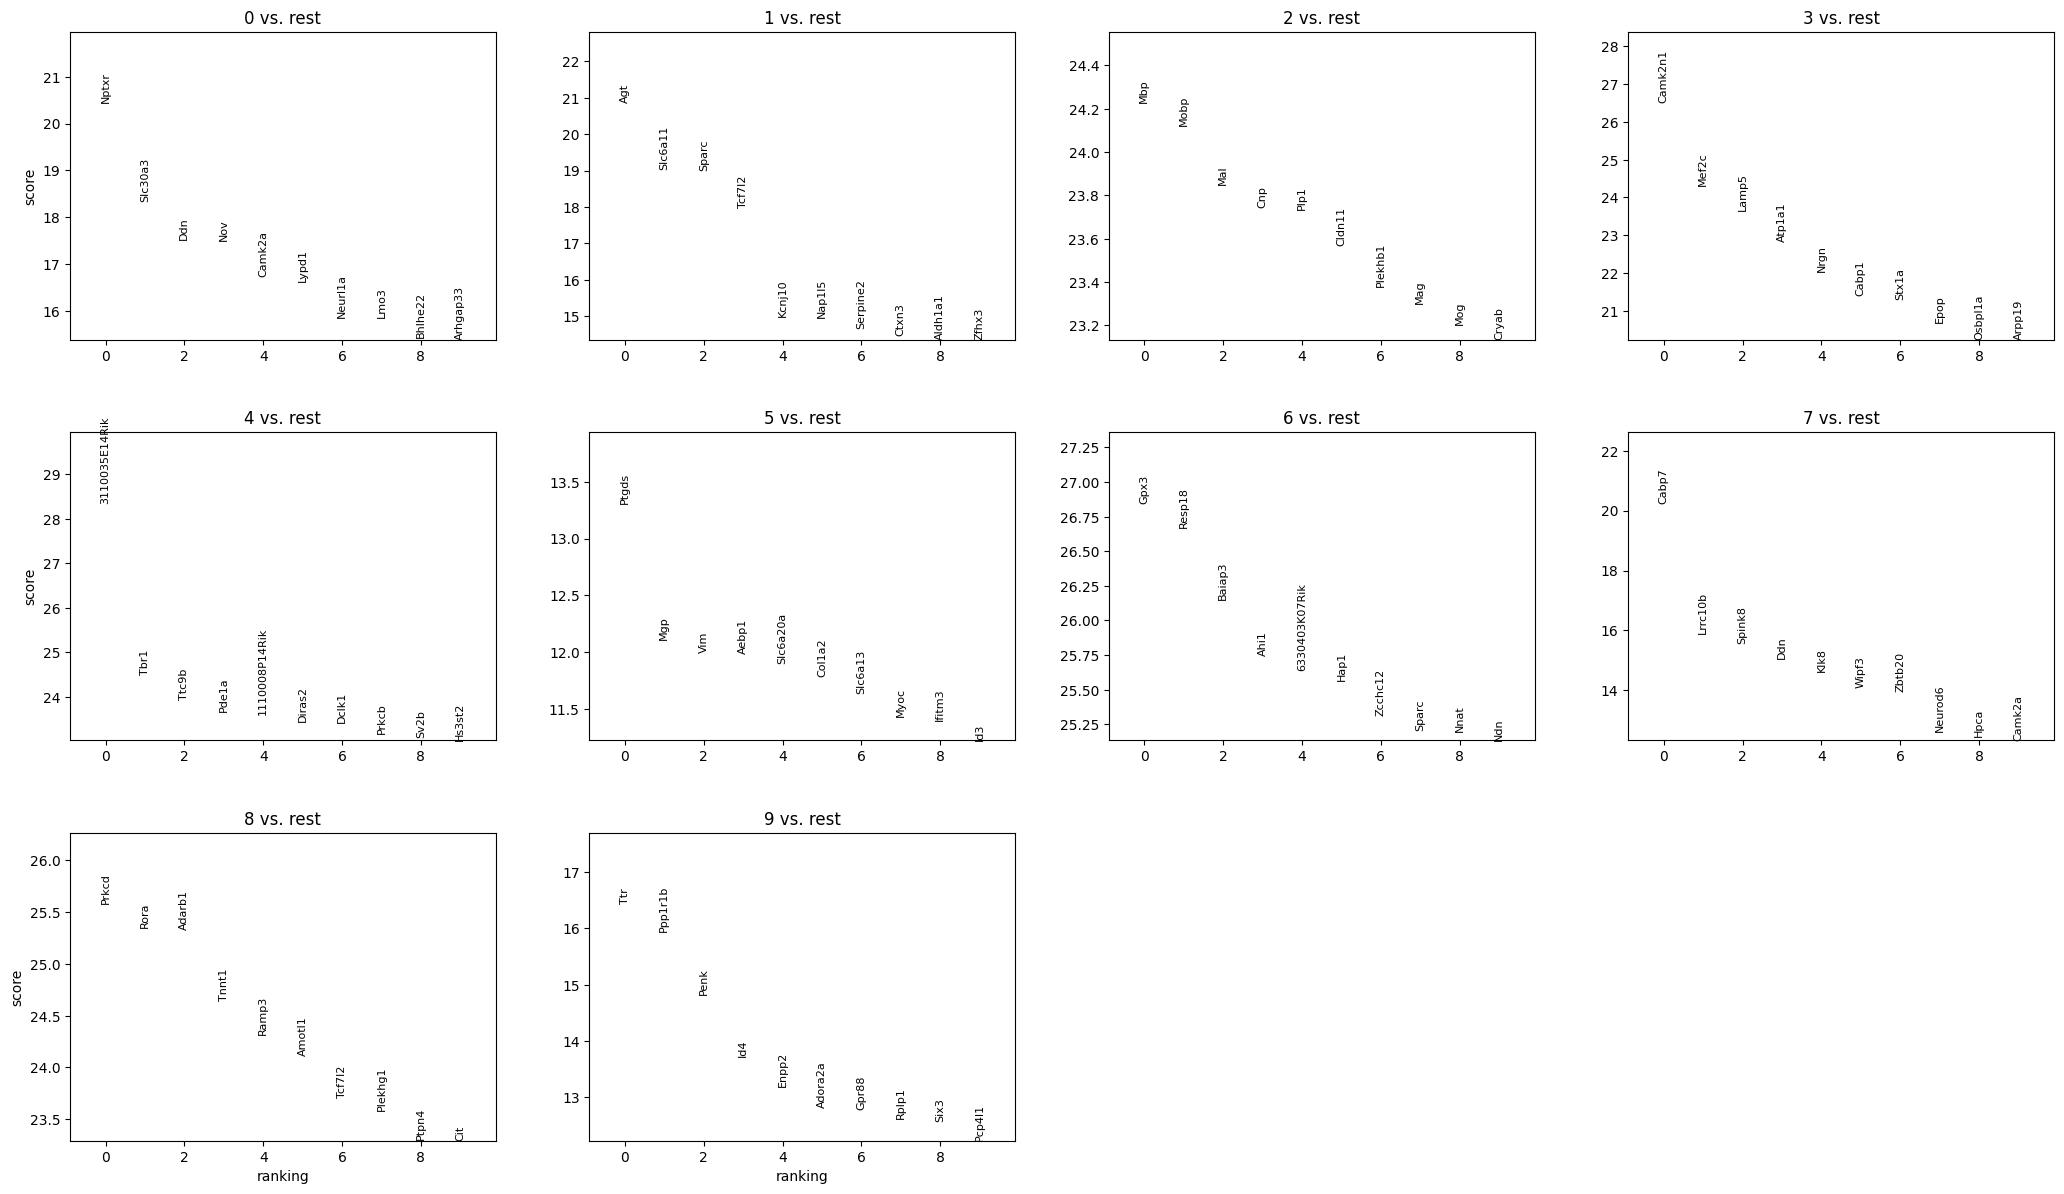

In [23]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon"
)

# safe extraction (NO indexing errors)
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)

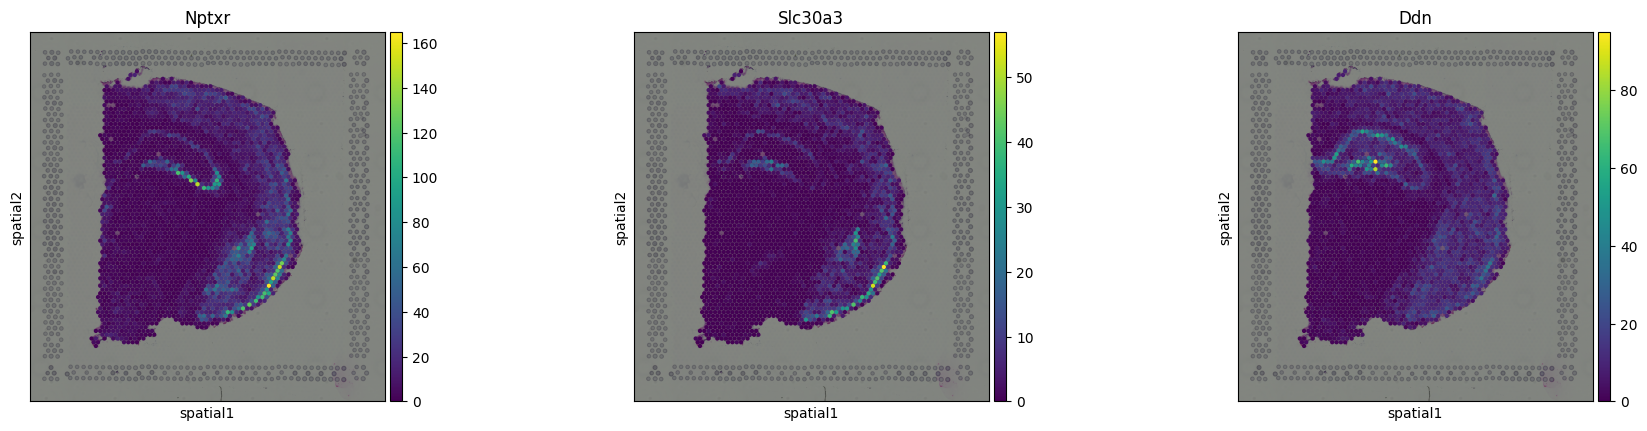

In [24]:
top_markers = sc.get.rank_genes_groups_df(adata, group="0")["names"].head(3)

sq.pl.spatial_scatter(
    adata,
    color=list(top_markers),
    size=1.5
)

In [26]:
import scanpy as sc

# recompute properly (safe)
sq.gr.spatial_autocorr(adata, mode="moran")

# convert results into a plottable table
adata.uns["moranI"].head()

,I,pval_norm,var_norm,pval_norm_fdr_bh
Itpka,0.656602,0.0,0.000131,0.0
Camk2n1,0.641730,0.0,0.000131,0.0
Fezf1,0.630500,0.0,0.000131,0.0
Baiap3,0.616508,0.0,0.000131,0.0
Shox2,0.606433,0.0,0.000131,0.0


In [27]:
import pandas as pd

# extract Moran results
moran_df = adata.uns["moranI"]

# show top spatially structured genes
moran_df = moran_df.sort_values("I", ascending=False).head(10)

moran_df

,I,pval_norm,var_norm,pval_norm_fdr_bh
Itpka,0.656602,0.0,0.000131,0.0
Camk2n1,0.641730,0.0,0.000131,0.0
Fezf1,0.630500,0.0,0.000131,0.0
Baiap3,0.616508,0.0,0.000131,0.0
Shox2,0.606433,0.0,0.000131,0.0
Arhgap36,0.588790,0.0,0.000131,0.0
Slc30a3,0.584765,0.0,0.000131,0.0
Gal,0.583541,0.0,0.000131,0.0
Foxg1,0.582656,0.0,0.000131,0.0
Irs4,0.577877,0.0,0.000131,0.0


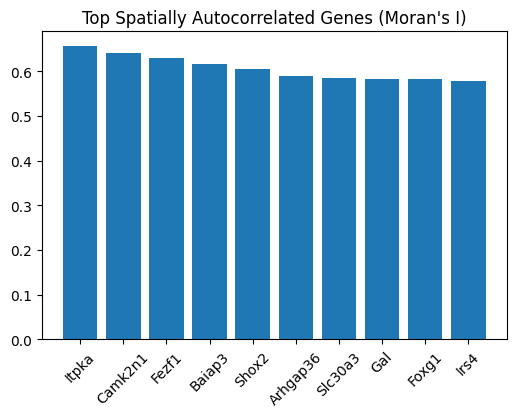

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(moran_df.index, moran_df["I"])
plt.xticks(rotation=45)
plt.title("Top Spatially Autocorrelated Genes (Moran's I)")
plt.show()